<a href="https://colab.research.google.com/github/sebarom06/econ3916-statsml/blob/main/Project/ECON_3916_Phase_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

N = 4870
              call        black    education    years_exp            h  \
count  4870.000000  4870.000000  4870.000000  4870.000000  4870.000000   
mean      0.080493     0.500000     3.618480     7.842916     0.502259   
std       0.272083     0.500051     0.714997     5.044612     0.500046   
min       0.000000     0.000000     0.000000     1.000000     0.000000   
25%       0.000000     0.000000     3.000000     5.000000     0.000000   
50%       0.000000     0.500000     4.000000     6.000000     1.000000   
75%       0.000000     1.000000     4.000000     9.000000     1.000000   
max       1.000000     1.000000     4.000000    44.000000     1.000000   

            female          eoe  
count  4870.000000  4870.000000  
mean      0.769199     0.291170  
std       0.421388     0.454349  
min       0.000000     0.000000  
25%       1.000000     0.000000  
50%       1.000000     0.000000  
75%       1.000000     1.000000  
max       1.000000     1.000000  
      Callback Rat

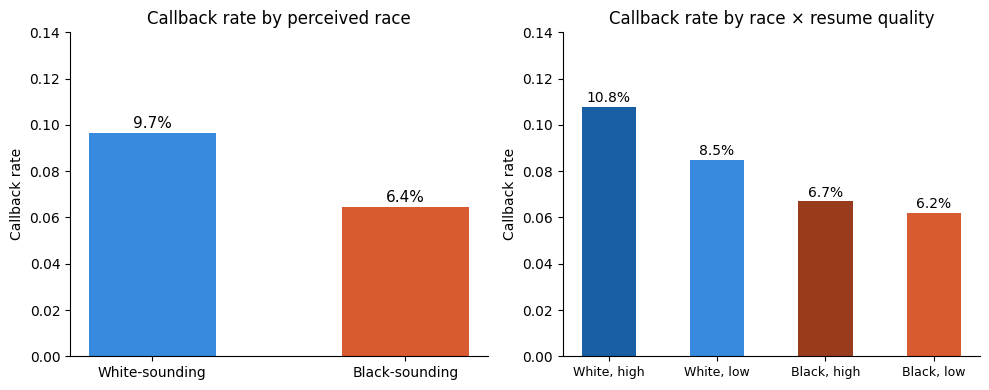

In [2]:
# Cell 1 - Markdown
# # ECON 3916 — Phase 3: Regression Analysis
# **Race-Based Discrimination in Job Hiring: Evidence from a Resume Audit**
# Dataset: Bertrand & Mullainathan (2004) — Labor Market Discrimination

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

df = pd.read_csv('labor_market_discrimination.csv')

df['black'] = (df['race'] == 'b').astype(int)
df['female'] = (df['sex'] == 'f').astype(int)

print(f'N = {len(df)}')
print(df[['call', 'black', 'education', 'years_exp', 'h', 'female', 'eoe']].describe())

callback_by_race = df.groupby('race')['call'].agg(['mean', 'count'])
callback_by_race.columns = ['Callback Rate', 'N']
callback_by_race['Callback Rate'] = callback_by_race['Callback Rate'].round(4)
print(callback_by_race)

raw_gap = callback_by_race.loc['w', 'Callback Rate'] - callback_by_race.loc['b', 'Callback Rate']
print(f'\nRaw callback gap (White − Black): {raw_gap:.4f}')

cb_quality = df.groupby(['race', 'h'])['call'].mean().unstack()
cb_quality.columns = ['Low quality', 'High quality']
print('Callback rate by race and resume quality:')
print(cb_quality.round(4))

formula_base = 'call ~ black + education + years_exp + h + female + eoe'
model_base = smf.ols(formula=formula_base, data=df).fit(cov_type='HC1')
print(model_base.summary())

formula_interact = 'call ~ black * h + education + years_exp + female + eoe'
model_interact = smf.ols(formula=formula_interact, data=df).fit(cov_type='HC1')
print(model_interact.summary())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

races = ['White-sounding', 'Black-sounding']
rates = [
    df[df['race']=='w']['call'].mean(),
    df[df['race']=='b']['call'].mean()
]
colors = ['#378ADD', '#D85A30']

axes[0].bar(races, rates, color=colors, width=0.5, edgecolor='none')
axes[0].set_ylabel('Callback rate')
axes[0].set_title('Callback rate by perceived race')
axes[0].set_ylim(0, 0.14)
for i, v in enumerate(rates):
    axes[0].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=11)
axes[0].spines[['top','right']].set_visible(False)

categories = ['White, high', 'White, low', 'Black, high', 'Black, low']
cb_vals = [
    df[(df['race']=='w') & (df['h']==1)]['call'].mean(),
    df[(df['race']=='w') & (df['l']==1)]['call'].mean(),
    df[(df['race']=='b') & (df['h']==1)]['call'].mean(),
    df[(df['race']=='b') & (df['l']==1)]['call'].mean(),
]
bar_colors = ['#185FA5', '#378ADD', '#993C1D', '#D85A30']
axes[1].bar(categories, cb_vals, color=bar_colors, width=0.5, edgecolor='none')
axes[1].set_ylabel('Callback rate')
axes[1].set_title('Callback rate by race × resume quality')
axes[1].set_ylim(0, 0.14)
axes[1].tick_params(axis='x', labelsize=9)
for i, v in enumerate(cb_vals):
    axes[1].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()